Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pathlib 

In [2]:
df = pd.read_csv("sentiment_sentence_level_enriched.csv")

In [3]:
df.head()

,artist,title,disorder,sentence_index,sentence,model,raw_output,valence,arousal,dominance
0,Quadeca,Burnin Bridges / Long Day (feat. IDK),depression,0,Highest To Lowest: Quadeca LyricsQuadeca's Son...,VAD,"[{'label': 'LABEL_1', 'score': 3.3642196655273...",0.143427,0.182110,0.049787
1,Quadeca,Burnin Bridges / Long Day (feat. IDK),depression,1,"(20,121,625)\n- BEAMIN' (8,999,725)\n- War!",VAD,"[{'label': 'LABEL_1', 'score': 3.6385209560394...",0.114133,0.319260,0.127583
2,Quadeca,Burnin Bridges / Long Day (feat. IDK),depression,2,(feat.,VAD,"[{'label': 'LABEL_2', 'score': 3.1772220134735...",0.065396,0.059895,0.088611
3,Quadeca,Burnin Bridges / Long Day (feat. IDK),depression,3,"Dax) (8,850,668)\n- Wii Music Fire (7,069,076)...",VAD,"[{'label': 'LABEL_1', 'score': 3.1627085208892...",-0.001970,0.081354,0.067098
4,Quadeca,Burnin Bridges / Long Day (feat. IDK),depression,4,"B. Lou) (6,183,298)\n- WHERE'D YOU GO?",VAD,"[{'label': 'LABEL_2', 'score': 3.0688900947570...",0.015637,-0.030077,0.034445


# One song plots

Two lines plot

In [4]:
def plot_song_va_path(
    df,
    song_id=None,
    song_title=None,
    id_col='song_id',
    title_col='title'
):

    if song_title is not None:
        if title_col not in df.columns:
            raise ValueError(f"Column '{title_col}' not found in dataframe.")
        song_df = df[df[title_col] == song_title].copy()

    elif song_id is not None:
        if id_col in df.columns:
            song_df = df[df[id_col] == song_id].copy()

        elif title_col in df.columns and np.issubdtype(type(song_id), np.integer):
            unique_titles = df[title_col].dropna().unique()

            if len(unique_titles) == 0:
                raise ValueError(f"No values found in '{title_col}' column.")

            if 1 <= int(song_id) <= len(unique_titles):
                resolved_title = unique_titles[int(song_id) - 1]
                song_df = df[df[title_col] == resolved_title].copy()
            else:
                raise ValueError(
                    f"No '{id_col}' column exists, and song_id={song_id} "
                    f"is out of range 1..{len(unique_titles)}."
                )
        else:
            raise ValueError(
                f"Column '{id_col}' not found. Use song_title='...' or pass a "
                f"1-based integer song_id to index '{title_col}'."
            )
    else:
        raise ValueError("Please provide song_id or song_title.")

    if song_df.empty:
        raise ValueError("No rows found for the selected song.")

    if 'sentence_index' not in song_df.columns:
        raise ValueError("Column 'sentence_index' not found in dataframe.")

    song_df = song_df.sort_values('sentence_index').reset_index(drop=True)
    x = song_df['sentence_index'].to_numpy()

    fig, ax = plt.subplots(figsize=(max(10, len(x) * 0.4), 5))

    ax.plot(
        x,
        song_df['valence'],
        marker='o',
        label='Valence',
        color='steelblue',
        linewidth=2
    )

    ax.plot(
        x,
        song_df['arousal'],
        marker='s',
        label='Arousal',
        color='tomato',
        linewidth=2
    )

    if 'dominance' in song_df.columns:
        ax.plot(
            x,
            song_df['dominance'],
            marker='^',
            label='Dominance',
            color='seagreen',
            linewidth=2,
            linestyle='--'
        )

    ax.axhline(0, linestyle='--', color='gray', alpha=0.4, linewidth=1)

    ax.set_xlim(x[0] - 0.5, x[-1] + 0.5)
    ax.set_ylim(-1.1, 1.1)

    ax.set_xlabel('Sentence index', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)

    ax.set_xticks(x)
    ax.tick_params(axis='x', labelsize=8)

    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    if title_col in song_df.columns:
        title = song_df[title_col].iloc[0]
        ax.set_title(f'Sentence-level VA timeline: {title}', fontsize=13)
    else:
        ax.set_title('Sentence-level VA timeline', fontsize=13)

    plt.tight_layout()
    plt.show()


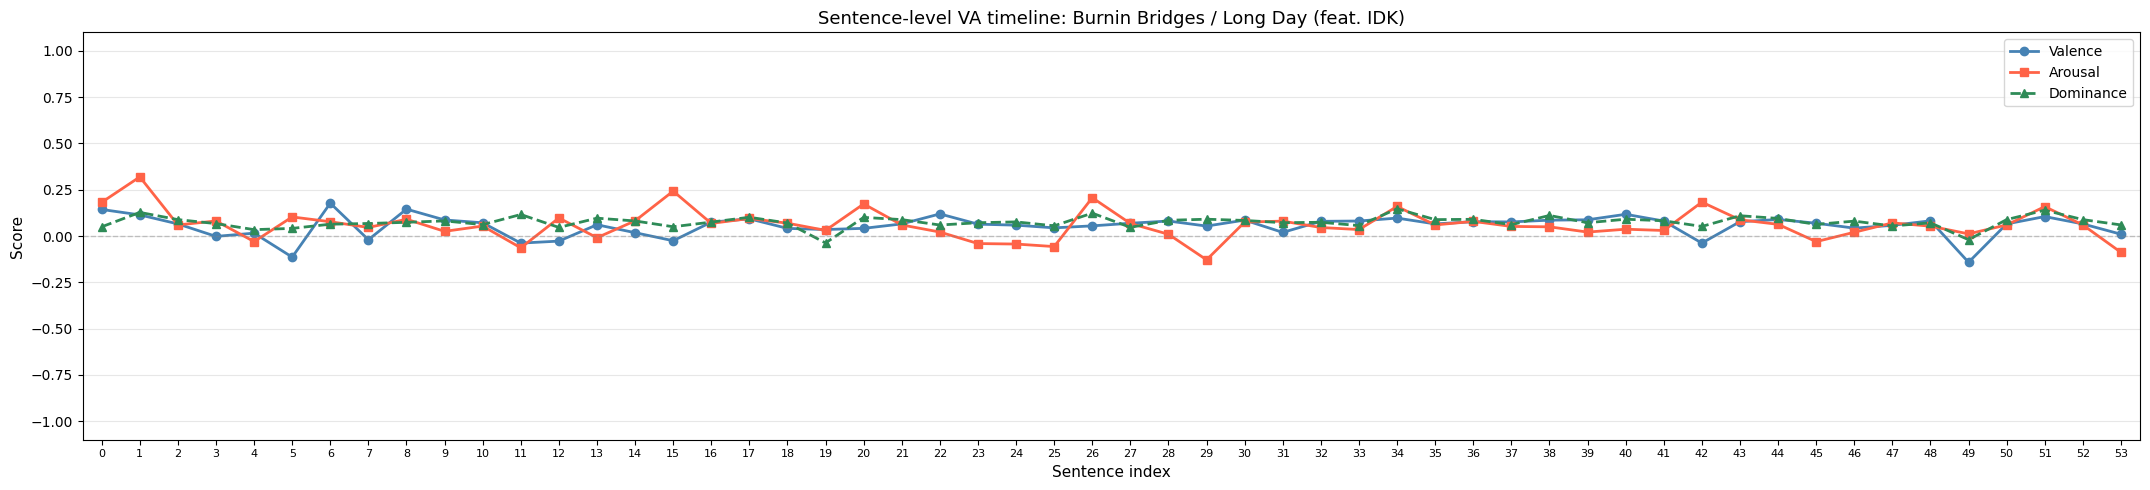

In [5]:
plot_song_va_path(df, song_id=1)

Spiral plot

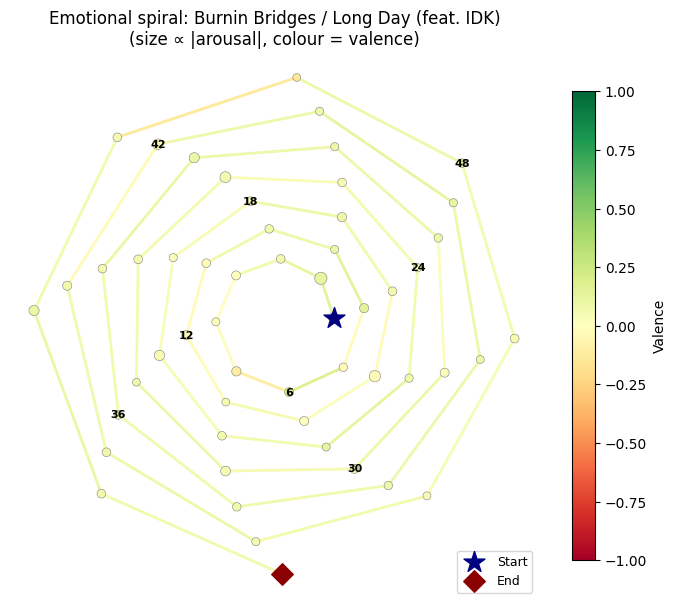

In [6]:
from matplotlib.collections import LineCollection


def plot_song_spiral(
    df,
    song_id=None,
    song_title=None,
    id_col='song_id',
    title_col='title'
):
    if song_title is not None:
        song_df = df[df[title_col] == song_title].copy()

    elif song_id is not None:
        if id_col in df.columns:
            song_df = df[df[id_col] == song_id].copy()
        else:
            unique_titles = df[title_col].dropna().unique()
            if 1 <= int(song_id) <= len(unique_titles):
                song_df = df[df[title_col] == unique_titles[int(song_id) - 1]].copy()
            else:
                raise ValueError(f"song_id={song_id} out of range 1..{len(unique_titles)}.")
    else:
        raise ValueError("Provide song_id or song_title.")

    if song_df.empty:
        raise ValueError("No rows found.")

    song_df = song_df.sort_values('sentence_index').reset_index(drop=True)

    n = len(song_df)
    n_turns = max(2, n / 8)

    theta = np.linspace(0, n_turns * 2 * np.pi, n)
    r = np.linspace(0.2, 1.0, n)

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    valence = song_df['valence'].to_numpy()
    arousal = song_df['arousal'].to_numpy()

    norm = plt.Normalize(-1, 1)

    fig, ax = plt.subplots(figsize=(7, 7))

    pts = np.array([x, y]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)

    lc = LineCollection(
        segs,
        cmap='RdYlGn',
        norm=norm,
        linewidth=2,
        zorder=2
    )
    lc.set_array(valence[:-1])

    ax.add_collection(lc)

    plt.colorbar(lc, ax=ax, label='Valence', shrink=0.7)

    sizes = np.abs(arousal) * 150 + 30

    ax.scatter(
        x,
        y,
        c=valence,
        cmap='RdYlGn',
        norm=norm,
        s=sizes,
        zorder=3,
        edgecolors='gray',
        linewidths=0.4
    )

    step = max(1, n // 8)

    for i in range(0, n, step):
        ax.annotate(
            str(int(song_df['sentence_index'].iloc[i])),
            (x[i], y[i]),
            fontsize=8,
            ha='center',
            va='center',
            fontweight='bold',
            color='black'
        )

    ax.scatter([x[0]], [y[0]], marker='*', s=250, color='navy', zorder=5, label='Start')
    ax.scatter([x[-1]], [y[-1]], marker='D', s=120, color='darkred', zorder=5, label='End')

    ax.legend(fontsize=9, loc='lower right')

    ax.set_aspect('equal')
    ax.axis('off')

    title = song_df[title_col].iloc[0] if title_col in song_df.columns else str(song_id or song_title)

    ax.set_title(
        f'Emotional spiral: {title}\n(size ∝ |arousal|, colour = valence)',
        fontsize=12
    )

    plt.tight_layout()
    plt.show()


plot_song_spiral(df, song_id=1)

Rearrange the dataset for 3d, arrow and labeled path plots

In [3]:
from mpl_toolkits.mplot3d import Axes3D

def get_song(df, song_id=None, song_title=None, id_col='song_id', title_col='title'):
    if song_title is not None:
        song_df = df[df[title_col] == song_title].copy()
    elif song_id is not None:
        if id_col in df.columns:
            song_df = df[df[id_col] == song_id].copy()
        else:
            unique_titles = df[title_col].dropna().unique()
            if 1 <= int(song_id) <= len(unique_titles):
                song_df = df[df[title_col] == unique_titles[int(song_id) - 1]].copy()
            else:
                raise ValueError(f"song_id={song_id} out of range 1..{len(unique_titles)}.")
    else:
        raise ValueError("Provide song_id or song_title.")

    if song_df.empty:
        raise ValueError("No rows found.")
    
    if 'sentence_index' not in song_df.columns:
        raise ValueError("Column 'sentence_index' not found in dataframe.")

    if 'valence' not in song_df.columns or 'arousal' not in song_df.columns:
        raise ValueError("Columns 'valence' and 'arousal' must be present in dataframe.")
    
    song_df = song_df.sort_values('sentence_index').reset_index(drop=True)
    
    return song_df

3D plot

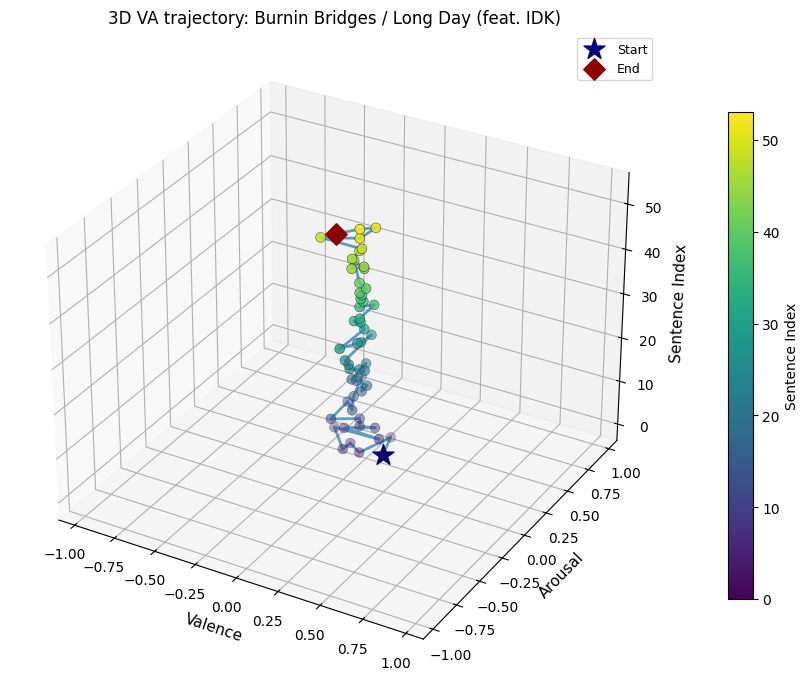

In [8]:
def plot_song_3d(df, song_id=None, song_title=None, id_col='song_id', title_col='title'):
    
    song_df = get_song(df, song_id=song_id, song_title=song_title, id_col=id_col, title_col=title_col)

    x = song_df['valence'].to_numpy()
    y = song_df['arousal'].to_numpy()
    z = song_df['sentence_index'].to_numpy()

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot(x, y, z, linewidth=2, alpha=0.7)
    sc = ax.scatter(x, y, z, c=z, cmap='viridis', s=50, edgecolors='black', linewidths=0.3)

    ax.scatter([x[0]], [y[0]], [z[0]], marker='*', s=250, color='navy', label='Start')
    ax.scatter([x[-1]], [y[-1]], [z[-1]], marker='D', s=120, color='darkred', label='End')

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)

    ax.set_xlabel('Valence', fontsize=11)
    ax.set_ylabel('Arousal', fontsize=11)
    ax.set_zlabel('Sentence Index', fontsize=11)

    title = song_df[title_col].iloc[0] if title_col in song_df.columns else str(song_id or song_title)
    ax.set_title(f'3D VA trajectory: {title}', fontsize=12)

    fig.colorbar(sc, ax=ax, pad=0.08, shrink=0.75, label='Sentence Index')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

plot_song_3d(df, song_id=1)

Arrow plot

In [9]:
def plot_song_arrow(df, song_id=None, song_title=None, id_col='song_id', title_col='title'):
    song_df = get_song(df, song_id=song_id, id_col=id_col, title_col=title_col)

    x = song_df['valence'].to_numpy()
    y = song_df['arousal'].to_numpy()
    n = len(song_df)

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.plot(x, y, alpha=0.35, linewidth=1.5)

    dx = np.diff(x)
    dy = np.diff(y)

    ax.quiver(
        x[:-1],
        y[:-1],
        dx,
        dy,
        np.arange(n - 1),
        cmap='viridis',
        angles='xy',
        scale_units='xy',
        scale=1,
        width=0.004,
        alpha=0.9
    )

    ax.scatter(x, y, cmap='viridis', s=25, zorder=3, edgecolors='black', linewidths=0.4)
    ax.scatter([x[0]], [y[0]], marker='*', s=250, color='navy', zorder=5, label='Start')
    ax.scatter([x[-1]], [y[-1]], marker='D', s=120, color='darkred', zorder=5, label='End')

    step = max(1, n // 8)
    for i in range(0, n, step):
        ax.annotate(
            str(int(song_df['sentence_index'].iloc[i])),
            (x[i], y[i]),
            fontsize=8,
            xytext=(4, 4),
            textcoords='offset points'
        )

    ax.axhline(0, linestyle='--', color='gray', alpha=0.4)
    ax.axvline(0, linestyle='--', color='gray', alpha=0.4)

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel('Valence', fontsize=11)
    ax.set_ylabel('Arousal', fontsize=11)

    title = song_df[title_col].iloc[0] if title_col in song_df.columns else str(song_id or song_title)
    ax.set_title(f'VA trajectory with arrows: {title}', fontsize=12)

    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_45969/692340563.py:29: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, cmap='viridis', s=25, zorder=3, edgecolors='black', linewidths=0.4)


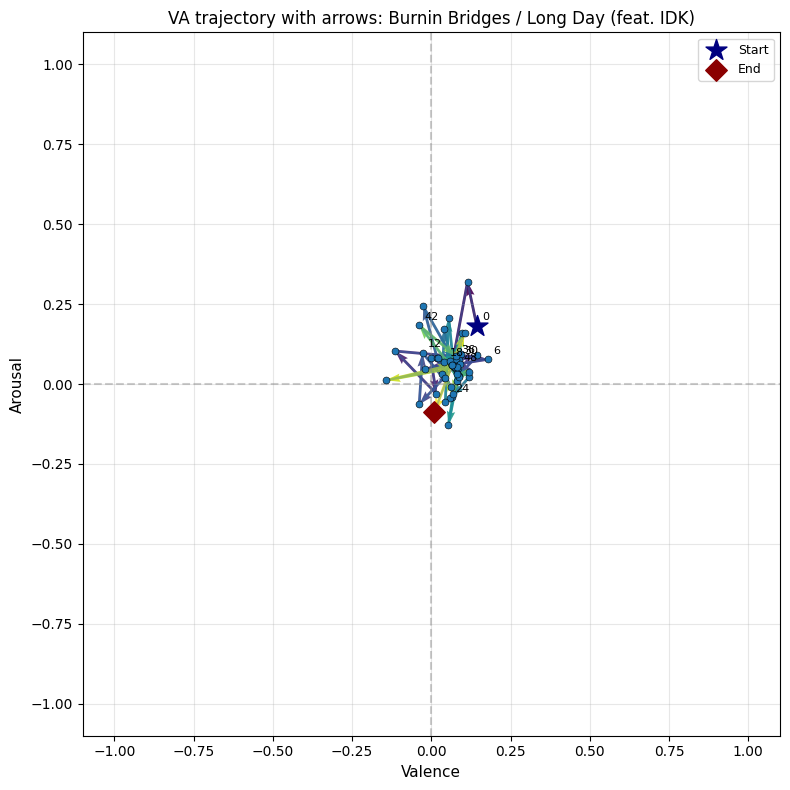

In [10]:
plot_song_arrow(df, song_id=1)

Cumulative VA plot

In [4]:
import os

def cumulative_va_path(df, song_id=None, song_title=None, id_col='song_id', title_col='title', save_frames=False, output_dir='frames_va_path', show=True):
    song_df = get_song(df, song_id=song_id, song_title=song_title, id_col=id_col, title_col=title_col)

    x = song_df['valence'].to_numpy()
    y = song_df['arousal'].to_numpy()
    sidx = song_df['sentence_index'].to_numpy()
    n = len(song_df)

    title = song_df[title_col].iloc[0] if title_col in song_df.columns else str(song_id or song_title)

    if save_frames:
        os.makedirs(output_dir, exist_ok=True)

    for i in range(1, n + 1):
        fig, ax = plt.subplots(figsize=(8, 8))

        xi = x[:i]
        yi = y[:i]

        if i > 1:
            ax.plot(xi, yi, linewidth=2, alpha=0.7)

        ax.scatter(xi, yi, c=np.arange(i), cmap='viridis', s=70, zorder=3, edgecolors='black', linewidth=0.4)

        ax.scatter(xi[0], yi[0], marker='*', s=250, color='navy', zorder=5, label='Start')
        ax.scatter(xi[-1], yi[-1], marker='D', s=120, color='darkred', zorder=5, label='Current')

        for j in range(i):
            ax.annotate(
                str(int(sidx[j])),
                (xi[j], yi[j]),
                fontsize=8,
                xytext=(4, 4),
                textcoords='offset points'
            )

        ax.axhline(0, linestyle='--', color='gray', alpha=0.4)
        ax.axvline(0, linestyle='--', color='gray', alpha=0.4)
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_xlabel('Valence', fontsize=11)
        ax.set_ylabel('Arousal', fontsize=11)
        ax.set_title(f'Cumulative VA path: {title}\nStep {i}/{n}', fontsize=12)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)
        plt.tight_layout()

        if save_frames:
            fig.savefig(os.path.join(output_dir, f'frame_{i:03d}.png'), dpi=150, bbox_inches='tight')

        if show:
            plt.show()
        else:
            plt.close()

Cumulative spiral VA plot

In [5]:
def cumulative_spiral(
    df,
    song_id=None,
    song_title=None,
    id_col='song_id',
    title_col='title',
    save_frames=False,
    output_dir='frames_cumulative_spiral',
    show=True
):
    song_df = get_song(
        df,
        song_id=song_id,
        song_title=song_title,
        id_col=id_col,
        title_col=title_col
    )

    x = song_df['valence'].to_numpy()
    y = song_df['arousal'].to_numpy()
    sidx = song_df['sentence_index'].to_numpy()
    n = len(song_df)

    title = song_df[title_col].iloc[0] if title_col in song_df.columns else str(song_id or song_title)

    n_turns = max(2.5, n / 7)
    theta = np.linspace(0, n_turns * 2 * np.pi, n)
    r = np.linspace(0.2, 1.0, n)
    spiral_x = r * np.cos(theta)
    spiral_y = r * np.sin(theta)
    label_step = max(1, n // 8)

    if save_frames:
        os.makedirs(output_dir, exist_ok=True)

    for i in range(1, n + 1):
        fig, ax = plt.subplots(figsize=(7, 7))

        if i > 1:
            ax.plot(spiral_x[:i], spiral_y[:i], color='lightgray', linewidth=1.5)

        sc = ax.scatter(
            spiral_x[:i],
            spiral_y[:i],
            c=x[:i],
            cmap='RdYlGn',
            norm=plt.Normalize(-1, 1),
            s=np.abs(y[:i]) * 150 + 30,
            edgecolors='gray',
            linewidths=0.4,
            zorder=3
        )

        ax.scatter(
            spiral_x[0],
            spiral_y[0],
            marker='*',
            s=250,
            color='navy',
            zorder=5,
            label='Start'
        )
        ax.scatter(
            spiral_x[i - 1],
            spiral_y[i - 1],
            marker='D',
            s=120,
            color='darkred',
            zorder=5,
            label='Current'
        )

        for j in range(0, i, label_step):
            ax.annotate(
                str(int(sidx[j])),
                (spiral_x[j], spiral_y[j]),
                fontsize=8,
                ha='center',
                va='center',
                color='#222222',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.65)
            )

        if (i - 1) % label_step != 0:
            ax.annotate(
                str(int(sidx[i - 1])),
                (spiral_x[i - 1], spiral_y[i - 1]),
                fontsize=8,
                ha='center',
                va='center',
                color='#222222',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.75)
            )

        cbar = fig.colorbar(sc, ax=ax, shrink=0.72, pad=0.01)
        cbar.set_label('Valence', fontsize=10)

        ax.legend(fontsize=9, loc='lower right', framealpha=0.9)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title(
            f'Cumulative emotional spiral: {title}\nStep {i}/{n}  |  size ∝ |arousal|, color = valence',
            fontsize=12,
            pad=14
        )
        plt.tight_layout()

        if save_frames:
            fig.savefig(
                os.path.join(output_dir, f'frame_{i:03d}.png'),
                dpi=170,
                bbox_inches='tight'
            )

        if show:
            plt.show()
        else:
            plt.close(fig)

Cumulative 3D plot

In [13]:
def cumulative_3d_path(df, song_id=None, song_title=None, id_col='song_id', title_col='title', save_frames=False, output_dir='frames_cumulative_3d', show=True):
    song_df = get_song(df, song_id=song_id, song_title=song_title, id_col=id_col, title_col=title_col)

    x = song_df['valence'].to_numpy()
    y = song_df['arousal'].to_numpy()
    z = song_df['sentence_index'].to_numpy()
    n = len(song_df)

    title = song_df[title_col].iloc[0] if title_col in song_df.columns else str(song_id or song_title)

    if save_frames:
        os.makedirs(output_dir, exist_ok=True)

    for i in range(1, n + 1):
        fig = plt.figure(figsize=(9, 7))
        ax = fig.add_subplot(111, projection='3d')

        xi = x[:i]
        yi = y[:i]
        zi = z[:i]

        if i > 1:
            ax.plot(xi, yi, zi, linewidth=2, alpha=0.7)

        sc = ax.scatter(xi, yi, zi, c=zi, cmap='viridis', s=50, edgecolors='black', linewidths=0.3)

        ax.scatter([xi[0]], [yi[0]], [zi[0]], marker='*', s=250, color='navy', label='Start')
        ax.scatter([xi[-1]], [yi[-1]], [zi[-1]], marker='D', s=120, color='darkred', label='Current')

        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_xlabel('Valence', fontsize=11)
        ax.set_ylabel('Arousal', fontsize=11)
        ax.set_zlabel('Sentence Index', fontsize=11)
        ax.set_title(f'Cumulative 3D VA path: {title}\nStep {i}/{n}', fontsize=12)
        fig.colorbar(sc, ax=ax, pad=0.08, shrink=0.75, label='Sentence Index')
        ax.legend(fontsize=9)

        plt.tight_layout()

        if save_frames:
            fig.savefig(os.path.join(output_dir, f'frame_{i:03d}.png'), dpi=150, bbox_inches='tight')

        if show:
            plt.show()
        else:
            plt.close(fig)

Make videos

In [ ]:
import imageio.v2 as imageio
from PIL import Image

def make_video(frames_dir, output_path='animation.mp4', fps=10):
    files = sorted([
        f for f in os.listdir(frames_dir)
        if f.endswith('.png')
    ])

    if not files:
        raise ValueError(f'No PNG frames found in {frames_dir}.')

    first_frame = Image.open(os.path.join(frames_dir, files[0])).convert('RGB')
    frame_size = first_frame.size

    with imageio.get_writer(output_path, mode='I', fps=fps) as writer:
        for f in files:
            path = os.path.join(frames_dir, f)
            image = Image.open(path).convert('RGB')
            if image.size != frame_size:
                image = image.resize(frame_size, Image.Resampling.LANCZOS)
            writer.append_data(np.asarray(image))

In [7]:
cumulative_spiral(df, song_id=1, show=False, save_frames=True, output_dir='spiral_frames')

make_video('spiral_frames', output_path='animation.mp4', fps=10)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (975, 1168) to (976, 1168) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


ValueError: All images in a movie should have same size